In [28]:
# conda activate chronocell

import os
import sys
import time
import pickle
import pandas as pd

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint/code")

import Chronocell
from reconstruct_RNA_history import *

from threadpoolctl import threadpool_limits
threadpool_limits(10)

In [29]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [30]:
Y = traj.X
Q = traj.Q[:, 0, :] 
tau = traj.tau # State transition times (global)
t = traj.t
theta = traj.theta
topo = traj.topo
state_grid = np.searchsorted(tau, t, side="left") - 1
state_grid[0] = 0 

# theta_ = theta.copy()
# a0 = theta_[:, 0] # Starting RNA abundance 
# a = theta_[:, 1:len(topo.flatten())] 
# beta = theta_[:, -2] # Splicing rate
# alpha = a * beta[:, None] # These values are divided by splicing rate; removing this factor now
# gamma = theta_[:, -1] # Degradation rate

In [31]:
chronocell_genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object

## Subset to genes with protein measurements

In [32]:
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

# Subset Chronocell data to genes of interest (with protein measurements)

mask = chronocell_genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist() # Genes to focus on
traj_genes = chronocell_genes['Gene_symbol'][mask]

Y = Y[:, mask, :]
theta = theta[mask, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [33]:
traj_genes

3         Cxcr4
9          Icos
12         Cd48
17        Cd24a
21         Cd63
24         Cd68
27         Ccr7
29      Cd300c2
33       Havcr2
48         Ighm
59         Irf4
63         Cd83
70       Lgals3
73         Il7r
82         Ly6e
88         Cd86
90        Cd200
93         Cd80
94         Btla
107       Ms4a1
109       Cd274
110         Fas
114      Entpd1
117        Dpp4
127       Itga4
129       Procr
135       Cd1d1
138       Vcam1
141      Notch2
150     Tnfrsf4
151    Tnfrsf18
152        Cd36
157        Flt3
158        Cd38
159         Kit
164       Cd207
167         Cd9
170       Klrk1
174        Cd8a
176     Clec12a
177      Clec9a
179        Pirb
182       Il4ra
183       Itgal
184       Itgax
186        Bst2
190       Lamp1
194       Itgb1
196        Fut4
201        Xcr1
203       Icam1
205        Jaml
Name: Gene_symbol, dtype: object

In [34]:
outdir = "data/RNA_history_per_gene"

## Reconstruct RNA

In [35]:
from threadpoolctl import threadpool_info
threadpool_info()

[{'user_api': 'blas',
  'internal_api': 'openblas',
  'num_threads': 10,
  'prefix': 'libopenblas',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libopenblasp-r0.3.29.so',
  'version': '0.3.29',
  'threading_layer': 'pthreads',
  'architecture': 'SkylakeX'},
 {'user_api': 'openmp',
  'internal_api': 'openmp',
  'num_threads': 10,
  'prefix': 'libgomp',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libgomp.so.1.0.0',
  'version': None}]

In [36]:
sparse_cutoff = 50

In [10]:
X_fwd_per_gene = []
states_per_gene = []

n_genes = Y.shape[1]

for gene_idx in range(0, n_genes):
    # Set max # of RNAs based on observed values
    U_max, S_max = max_RNAs(Y, gene_idx)

    print("==================================")
    print(f"Starting gene {gene_idx + 1} out of {n_genes}")
    print("U_max, S_max:", U_max, S_max)
    
    gene_name = traj_genes.iloc[gene_idx]
     
    states, index_for = enumerate_states(U_max, S_max)

    beta_j = beta[gene_idx]
    gamma_j = gamma[gene_idx] 
    alpha_j = alpha[gene_idx, :]
    Y_j = Y[:, gene_idx, :]

    # Make generator matrix (per transcription rate)
    A = []
    for i in range(0, alpha.shape[1]):
        rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
        if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
            A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
        else:
            A1 = create_transition_matrix(rxns, states, index_for, U_max, S_max)
        A.append(A1)
        
    # Calculate forward probability distributions (needed for reverse generator)
    alpha0 = a0[gene_idx] * beta_j
    pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
    start = time.perf_counter() 
    X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
    end = time.perf_counter()
    print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")
    
    # Calculate backward probability distributions
    
    start = time.perf_counter()
    if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
        # Use this function for large state spaces
        X_bw = backward_distribution_sparse_to_dense(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution_sparse_to_dense(): {end - start:.6f} seconds")
    else:
        X_bw = backward_distribution(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution(): {end - start:.6f} seconds")

    # Save highest probability state
    start = time.perf_counter()
    U_per_cell, S_per_cell = highest_prob_state_in_X_bw(X_bw, Q, states) 
    end = time.perf_counter()
    print(f"Elapsed time for highest_prob_state_in_X_bw(): {end - start:.6f} seconds")
         
    with open(f"{outdir}/{prefix}_{gene_name}_U_RNA_history.pkl", "wb") as f:
        pickle.dump(U_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    with open(f"{outdir}/{prefix}_{gene_name}_S_RNA_history.pkl", "wb") as f:
        pickle.dump(S_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    X_fwd_per_gene.append(X_fwd)
    states_per_gene.append(states)
    
    get_expm.cache_clear()
    get_A_rev.cache_clear()
    get_expm_rev.cache_clear()
    get_A_rev_sparse_to_dense.cache_clear()
    get_expm_rev_sparse_to_dense.cache_clear()
    
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "wb") as f:
    pickle.dump(X_fwd_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
with open(f"data/{prefix}_states_per_gene.pkl", "wb") as f:
    pickle.dump(states_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)

Starting gene 1 out of 52
U_max, S_max: 5 14


In [37]:
# Just X_fwd

X_fwd_per_gene = []
states_per_gene = []

n_genes = Y.shape[1]

for gene_idx in range(0, n_genes):
    # Set max # of RNAs based on observed values
    U_max, S_max = max_RNAs(Y, gene_idx)

    print("==================================")
    print(f"Starting gene {gene_idx + 1} out of {n_genes}")
    print("U_max, S_max:", U_max, S_max)
    
    gene_name = traj_genes.iloc[gene_idx]
     
    states, index_for = enumerate_states(U_max, S_max)

    beta_j = beta[gene_idx]
    gamma_j = gamma[gene_idx] 
    alpha_j = alpha[gene_idx, :]
    Y_j = Y[:, gene_idx, :]

    # Make generator matrix (per transcription rate)
    A = []
    for i in range(0, alpha.shape[1]):
        rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
        if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
            A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
        else:
            A1 = create_transition_matrix(rxns, states, index_for, U_max, S_max)
        A.append(A1)
    
    # Calculate forward probability distributions (needed for reverse generator)
    alpha0 = a0[gene_idx] * beta_j
    pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
    start = time.perf_counter() 
    X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
    end = time.perf_counter()
    print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")
    
    # Calculate backward probability distributions
    
    X_fwd_per_gene.append(X_fwd)
    states_per_gene.append(states)
    
    get_expm.cache_clear()

with open(f"data/{prefix}_X_fwd_per_gene.pkl", "wb") as f:
    pickle.dump(X_fwd_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
with open(f"data/{prefix}_states_per_gene.pkl", "wb") as f:
    pickle.dump(states_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)

Starting gene 1 out of 52
U_max, S_max: 5 14
Elapsed time for forward_distribution_blocked(): 0.287963 seconds
Starting gene 2 out of 52
U_max, S_max: 16 9
Elapsed time for forward_distribution_blocked(): 0.190842 seconds
Starting gene 3 out of 52
U_max, S_max: 4 8
Elapsed time for forward_distribution_blocked(): 0.133870 seconds
Starting gene 4 out of 52
U_max, S_max: 4 18
Elapsed time for forward_distribution_blocked(): 0.110682 seconds
Starting gene 5 out of 52
U_max, S_max: 4 48
Elapsed time for forward_distribution_blocked(): 1.003699 seconds
Starting gene 6 out of 52
U_max, S_max: 2 8
Elapsed time for forward_distribution_blocked(): 0.088064 seconds
Starting gene 7 out of 52
U_max, S_max: 25 116
Elapsed time for forward_distribution_blocked(): 1.863785 seconds
Starting gene 8 out of 52
U_max, S_max: 3 7
Elapsed time for forward_distribution_blocked(): 0.043365 seconds
Starting gene 9 out of 52
U_max, S_max: 30 11
Elapsed time for forward_distribution_blocked(): 0.304375 seconds
S

## Compare reconstructed vs. simulated trajectories

In [41]:
import glob
import pickle
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

from simulate_data import *

In [42]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

# Get traj object from running Chronocell

with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Extract varies objects/parameters needed to simulate data

Y = traj.X
Q = traj.Q[:, 0, :] 
t = traj.t
theta = traj.theta
tau = traj.tau # State transition times (global)
topo = traj.topo 
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 

# Subset data to genes of interest (with protein measurements)

genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()

Y = Y[:, gene_idx, :]
theta = theta[gene_idx, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [43]:
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)
    
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)

In [44]:
# Generate ground-truth simulated data

n = 2000 # No. cells
random_seed = 666

Y_observed, Y_sim, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

In [45]:
# Focus on one gene:

gene_idx = np.where(traj_genes == "Lamp1")[0][0]

In [46]:
traj_genes.iloc[gene_idx]

'Lamp1'

In [47]:
# Get forward trajectories
states = states_per_gene[gene_idx]
X_fwd = X_fwd_per_gene[gene_idx]
U_fwd, S_fwd = highest_prob_state_in_X_fwd(X_fwd, states)

# Load backward trajectories
gene_str = traj_genes.iloc[gene_idx]
pattern = os.path.join(outdir, f"*_{gene_str}_S*")
file = glob.glob(pattern)[0]

with open(file, "rb") as f:
    X_bw_S = pickle.load(f)

Text(0, 0.5, '# molecules')

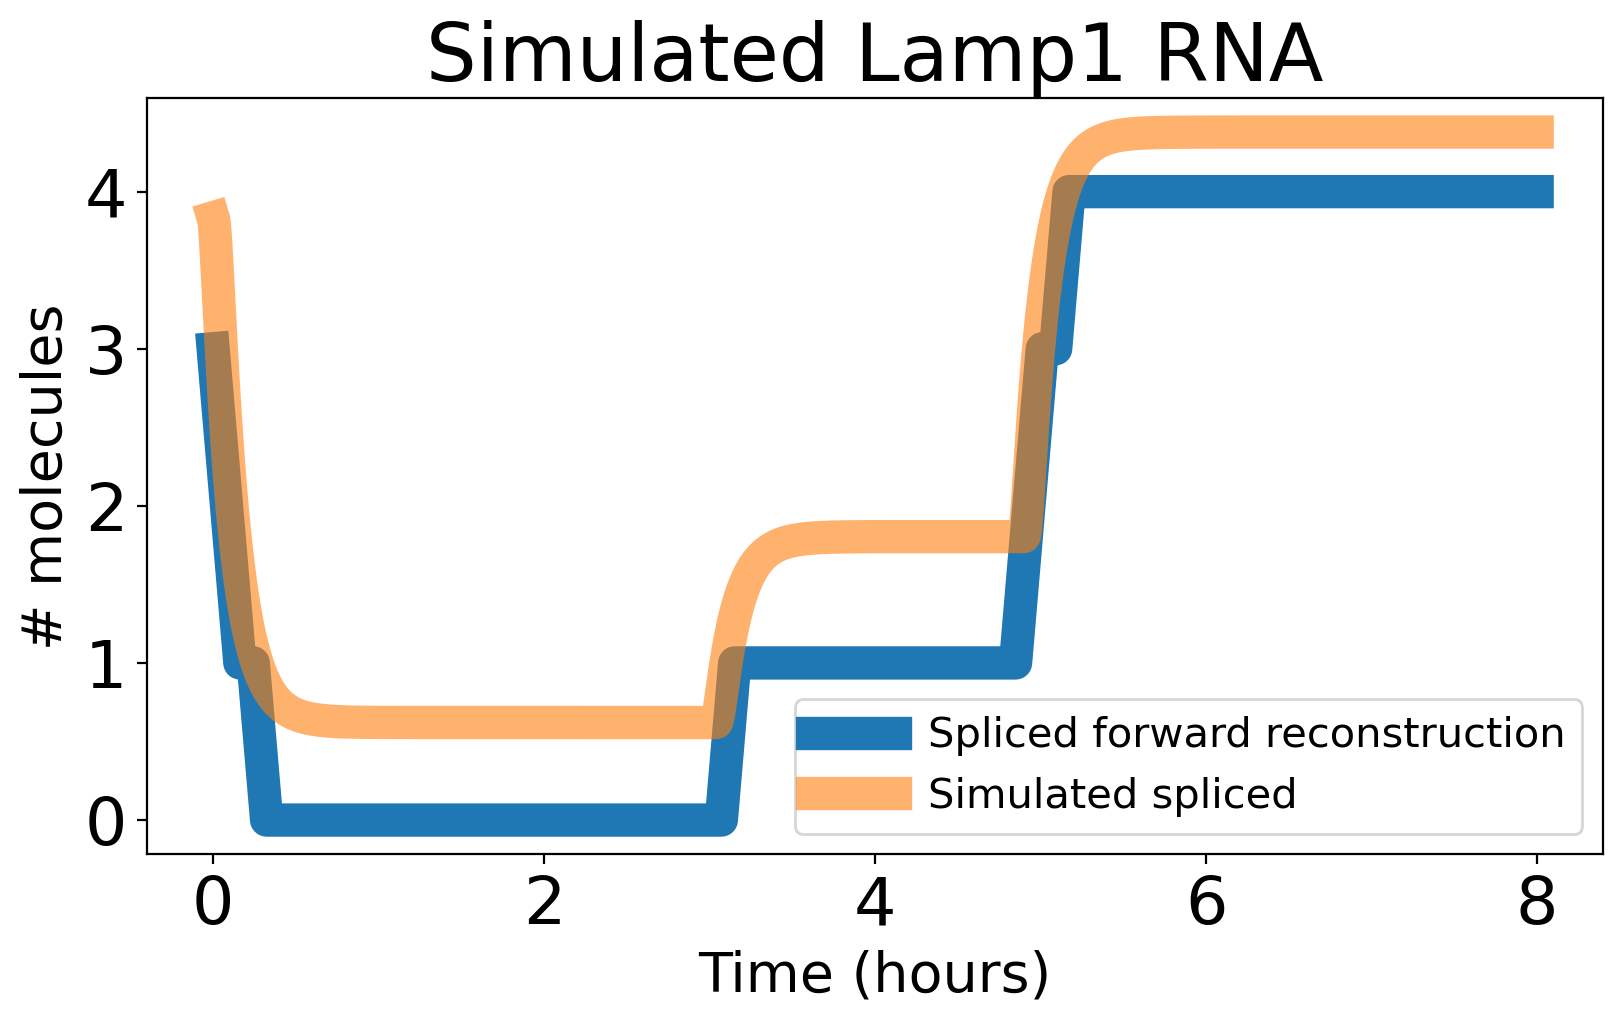

In [48]:
# First compare simulated vs. forward trajectory

# fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
# ax.plot(t, U_fwd, label="Unspliced forward reconstruction")
# ax.plot(true_t, Y_sim[:, gene_idx, 0], label="Simulated unspliced")
# ax.legend(fontsize=15)
# ax.set_xlabel("Time (hours)", fontsize=20)
# ax.set_ylabel("# molecules", fontsize=20)

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, S_fwd, label="Spliced forward reconstruction")
ax.plot(true_t, Y_sim[:, gene_idx, 1], label="Simulated spliced", alpha=0.6)
ax.legend(fontsize=15)
ax.set_title(f"Simulated {traj_genes.iloc[gene_idx]} RNA")
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

Text(0, 0.5, '# molecules')

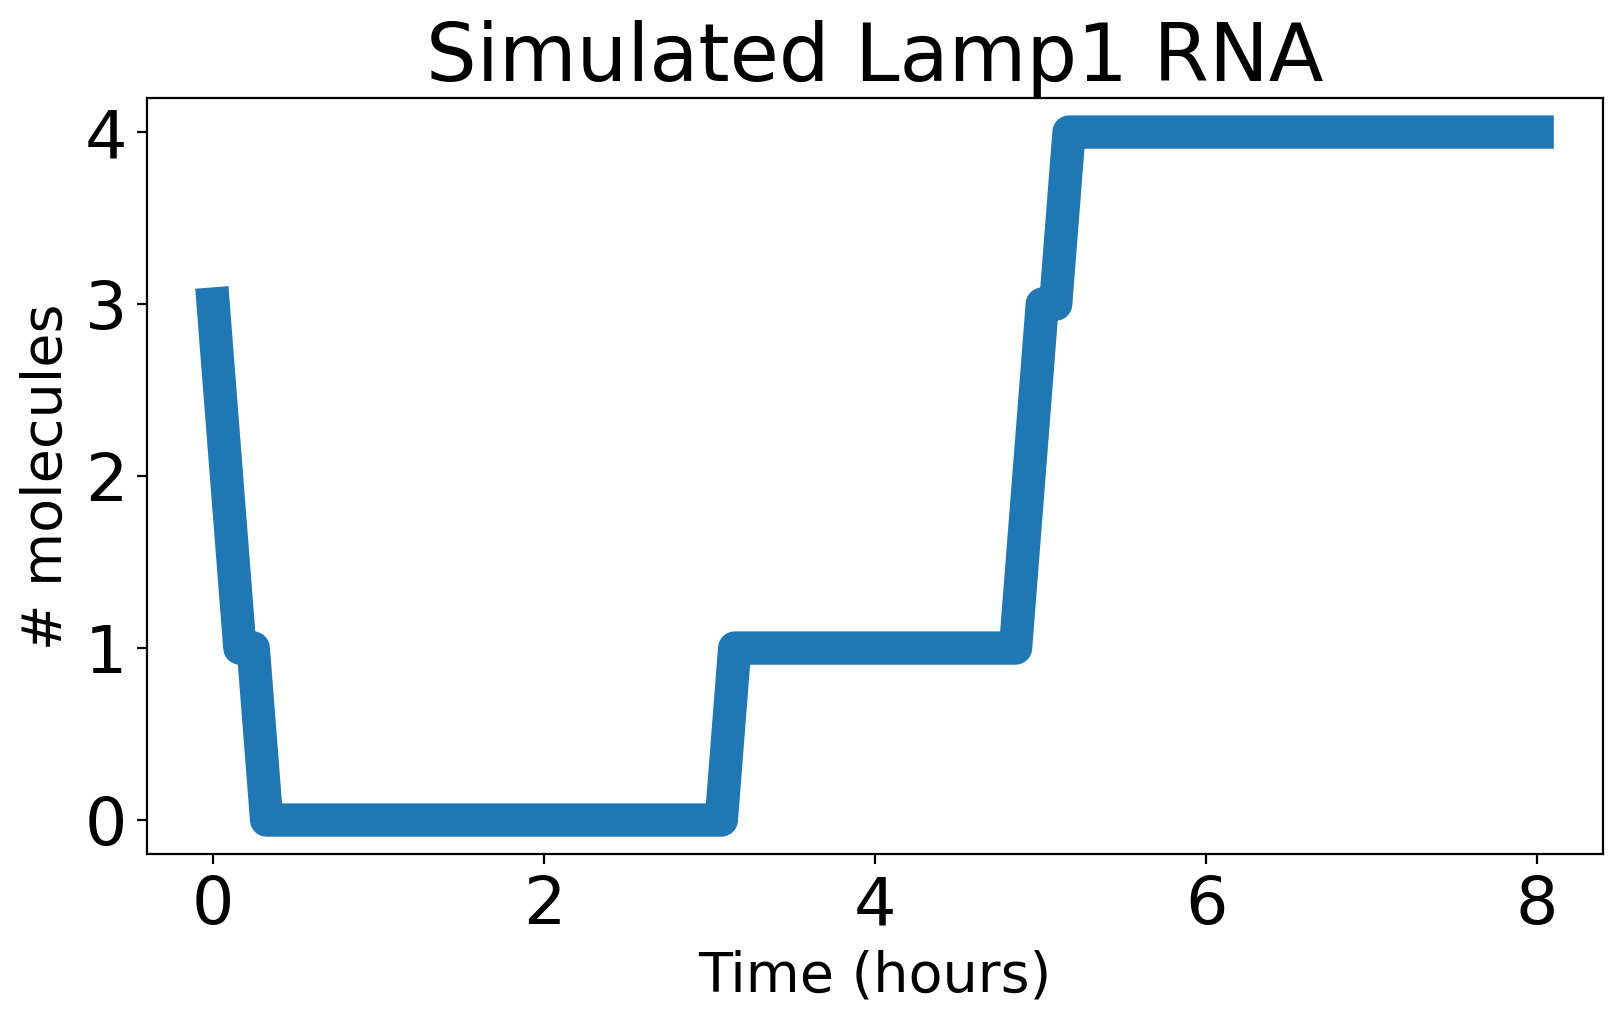

In [49]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, S_fwd, label="Spliced forward reconstruction")
ax.set_title(f"Simulated {traj_genes.iloc[gene_idx]} RNA")
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

Text(0, 0.5, '# molecules')

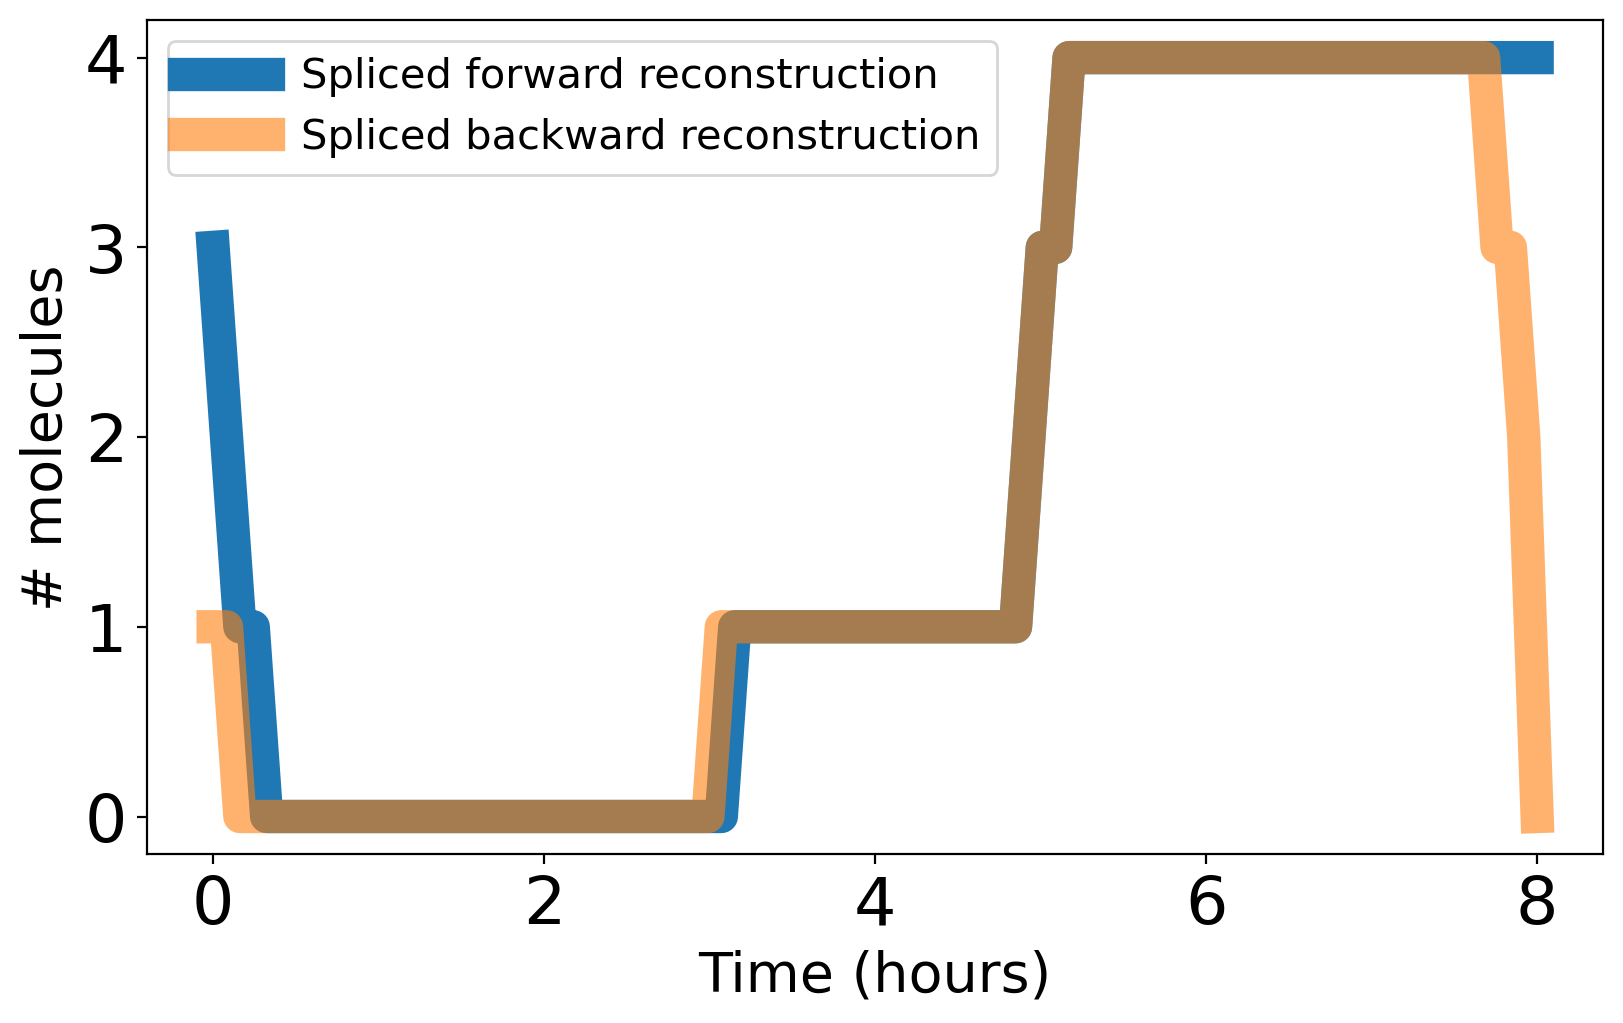

In [50]:
# Now compare forward vs. backward trajectory

# Pick cell at the end of trajectory:

t_obs = np.argmax(Q, axis=1)
cell_inds = np.where(t_obs == 99)[0]

i = 0

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, S_fwd, label="Spliced forward reconstruction")
ax.plot(t, X_bw_S[cell_inds[i], :], label="Spliced backward reconstruction", alpha=0.6)
ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

Text(0, 0.5, '# molecules')

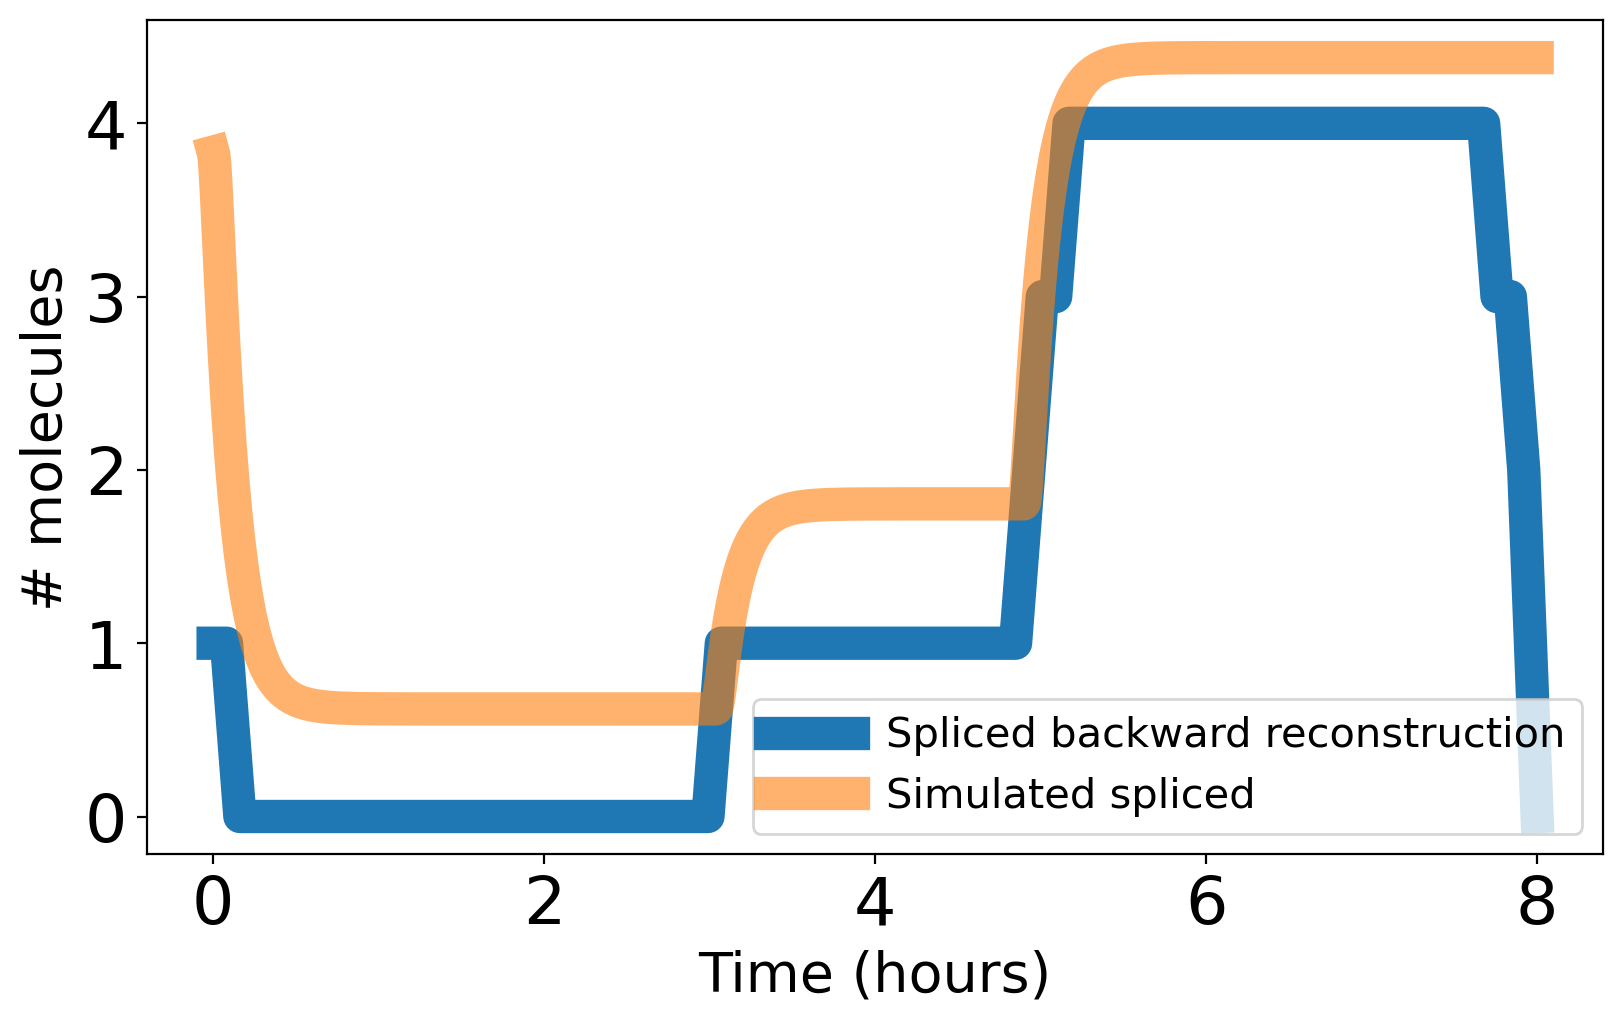

In [51]:
# Now compare simulated vs. backward trajectory

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, X_bw_S[cell_inds[i], :], label="Spliced backward reconstruction")
ax.plot(true_t, Y_sim[:, gene_idx, 1], label="Simulated spliced", alpha=0.6)
ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)